In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [3]:
PROJECT_ROOT = Path.cwd().parent
gangnam_df = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "gangnam" / "gangnam_2016_2025.csv")
seocho_df = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "seocho" / "seocho_2016_2025.csv")

In [4]:
df = pd.concat([gangnam_df, seocho_df], ignore_index=True)

df["dealAmount"] = (
    df["dealAmount"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)
df["is_cancelled"] = df["cdealType"].astype(str).str.strip() == "O"

df_clean = df[~df["is_cancelled"]].copy()
len(df), len(df_clean)

(69686, 67743)

### 가설 1: 건축연한이 평당 가격에 영향을 미칠 것이다

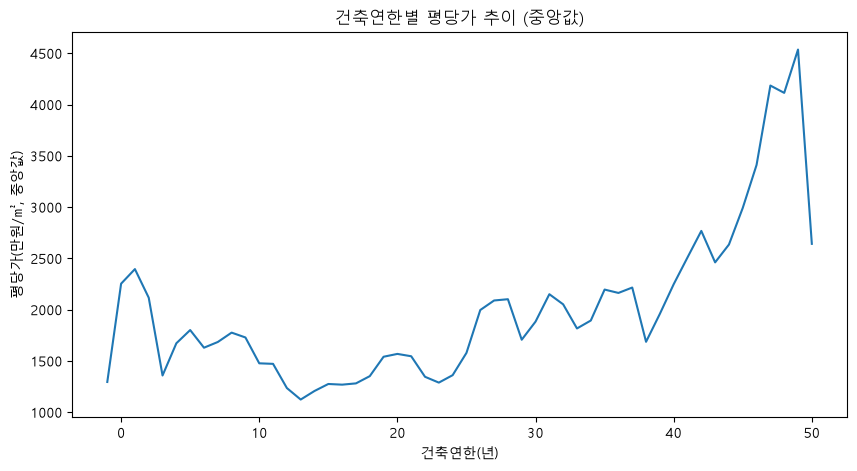

In [5]:
df_clean["age"] = df_clean["dealYear"] - df_clean["buildYear"]
df_clean["price_per_area"] = df_clean["dealAmount"] / df_clean["excluUseAr"]

fig, ax = plt.subplots(figsize=(10, 5))
df_clean.groupby("age")["price_per_area"].median().plot(ax=ax)
ax.set_title("건축연한별 평당가 추이 (중앙값)")
ax.set_xlabel("건축연한(년)")
ax.set_ylabel("평당가(만원/㎡, 중앙값)")
plt.show()

In [6]:
df_clean["is_presale"] = df_clean["age"] < 0
completed = df_clean[~df_clean["is_presale"]].copy()
presale = df_clean[df_clean["is_presale"]]

### 가설 2: 층수가 가격에 영향을 미칠 것이다

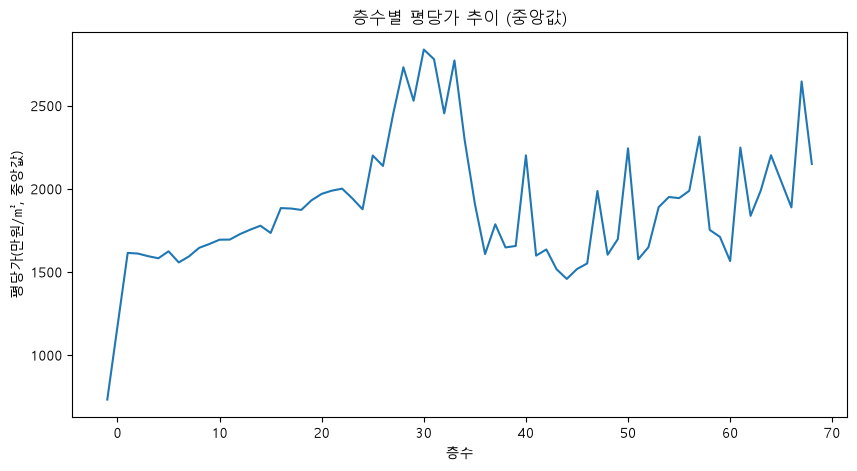

count    67742.000000
mean         9.273272
std          7.118316
min         -1.000000
25%          4.000000
50%          8.000000
75%         12.000000
max         68.000000
Name: floor, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
completed.groupby("floor")["price_per_area"].median().plot(ax=ax)
ax.set_title("층수별 평당가 추이 (중앙값)")
ax.set_xlabel("층수")
ax.set_ylabel("평당가(만원/㎡, 중앙값)")
plt.show()

completed["floor"].describe()

### 가설 3: 거래시기(계절)에 따라 거래량과 가격이 다를 것이다

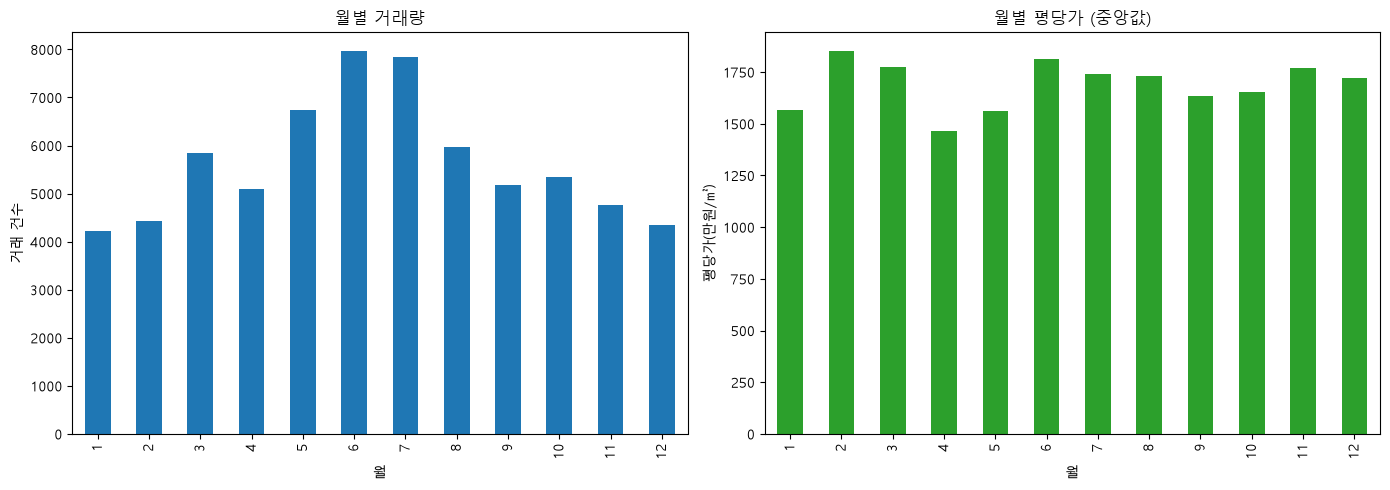

In [8]:
completed["deal_month_only"] = completed["dealMonth"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

completed.groupby("deal_month_only").size().plot(kind="bar", ax=axes[0], color="tab:blue")
axes[0].set_title("월별 거래량")
axes[0].set_xlabel("월")
axes[0].set_ylabel("거래 건수")

completed.groupby("deal_month_only")["price_per_area"].median().plot(kind="bar", ax=axes[1], color="tab:green")
axes[1].set_title("월별 평당가 (중앙값)")
axes[1].set_xlabel("월")
axes[1].set_ylabel("평당가(만원/㎡)")

plt.tight_layout()
plt.show()

### 가설 4: 평형이 작을수록 평당가가 더 높을 것이다 (국평 프리미엄)

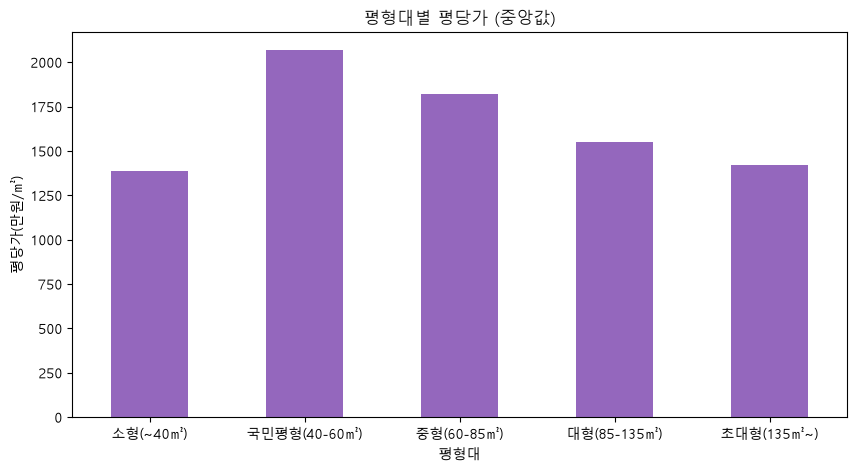

area_group
소형(~40㎡)        1387.633112
국민평형(40-60㎡)    2065.949949
중형(60-85㎡)      1818.181818
대형(85-135㎡)     1549.538269
초대형(135㎡~)      1422.924901
Name: price_per_area, dtype: float64

In [9]:
bins = [0, 40, 60, 85, 135, 300]
labels = ["소형(~40㎡)", "국민평형(40-60㎡)", "중형(60-85㎡)", "대형(85-135㎡)", "초대형(135㎡~)"]
completed["area_group"] = pd.cut(completed["excluUseAr"], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(10, 5))
completed.groupby("area_group", observed=True)["price_per_area"].median().plot(kind="bar", ax=ax, color="tab:purple")
ax.set_title("평형대별 평당가 (중앙값)")
ax.set_xlabel("평형대")
ax.set_ylabel("평당가(만원/㎡)")
plt.xticks(rotation=0)
plt.show()

completed.groupby("area_group", observed=True)["price_per_area"].median()

### 가설 5: 강남구와 서초구는 가격 수준과 변동성이 다를 것이다

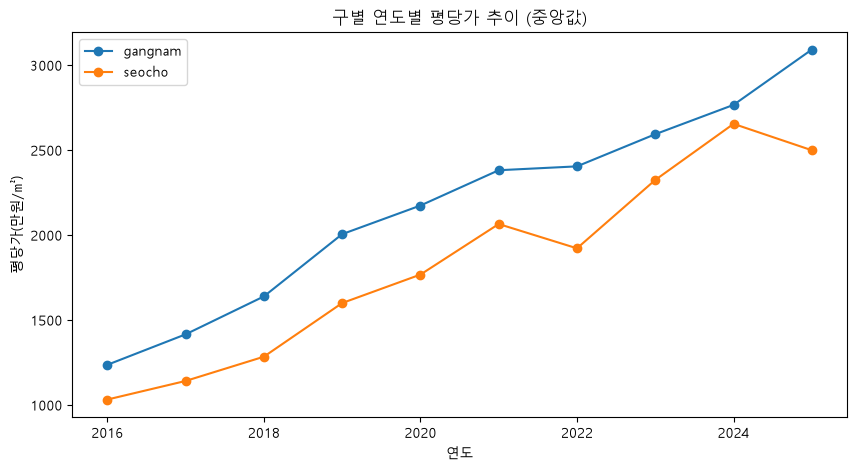

,count,mean,std,min,25%,50%,75%,max
gu_name,,,,,,,,
gangnam,38110.0,2013.931030,950.515775,295.663601,1284.317270,1817.869755,2555.021503,8767.809613
seocho,29632.0,1838.066179,1055.484590,300.679643,1052.351115,1532.101363,2301.150575,8472.581784


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for gu, group in completed.groupby("gu_name"):
    group.groupby("dealYear")["price_per_area"].median().plot(ax=ax, label=gu, marker="o")

ax.set_title("구별 연도별 평당가 추이 (중앙값)")
ax.set_xlabel("연도")
ax.set_ylabel("평당가(만원/㎡)")
ax.legend()
plt.show()

completed.groupby("gu_name")["price_per_area"].describe()